Day 10 — Task

Polynomial Features & Polynomial Regression

Until now your models could only learn straight-line relationships:

𝑦
=
𝑤
𝑥
+
𝑏
y=wx+b

But many real-world relationships are curved.

Example:

population growth

stock trends

temperature patterns

These cannot be captured by a straight line.

Polynomial regression allows the model to learn:

𝑦
=
𝑎
𝑥
2
+
𝑏
𝑥
+
𝑐
y=ax
2
+bx+c

or even higher powers.

Core Idea

Instead of giving the model only x, we also give it x², x³, ...

Example dataset:

x	x²
1	1
2	4
3	9
4	16

Now the model becomes:

𝑦
=
𝑤
1
𝑥
+
𝑤
2
𝑥
2
+
𝑏
y=w
1
	​

x+w
2
	​

x
2
+b

The model is still linear in weights, but the relationship becomes nonlinear in x.

Day 10 Coding Task
Dataset
import numpy as np

X = np.array([1,2,3,4,5], dtype=float)
y = np.array([1,4,9,16,25], dtype=float)

This follows:

𝑦
=
𝑥
2
y=x
2

A straight line cannot fit this.

Step 1 — Create Polynomial Features
X_poly = np.column_stack((X, X**2))

Now your input becomes:

x	x²
1	1
2	4
3	9
4	16
5	25
Step 2 — Initialize Parameters

You now have two weights:

w = np.zeros(2)
b = 0
learning_rate = 0.001
Step 3 — Prediction
𝑦
𝑝
𝑟
𝑒
𝑑
=
𝑤
1
𝑥
+
𝑤
2
𝑥
2
+
𝑏
y
pred
	​

=w
1
	​

x+w
2
	​

x
2
+b

Code:

y_pred = np.dot(X_poly, w) + b
Step 4 — Loss

Use MSE:

loss = np.mean((y_pred - y)**2)
Step 5 — Gradients
dw = (2/len(X_poly)) * np.dot(X_poly.T, (y_pred - y))
db = (2/len(X_poly)) * np.sum(y_pred - y)
Step 6 — Update Parameters
w -= learning_rate * dw
b -= learning_rate * db
Step 7 — Training Loop

Train for about 5000 iterations.

Print loss occasionally.

Expected Result

The model should learn something close to:

w1 ≈ 0
w2 ≈ 1
b ≈ 0

Meaning the model discovered:

𝑦
≈
𝑥
2
y≈x
2
What This Teaches

Polynomial features allow models to learn:

curves

nonlinear relationships

more complex patterns

Day 10 Report

Send this after completing:

Day 10

• What I studied:
• What I implemented:
• What I understood well:
• What confused me:
• Time spent:

Final weights:
Final bias:
Final loss:

Iteration 0, Loss: 195.8000, w: [0.09   0.3916], b: 0.022
Iteration 500, Loss: 0.0065, w: [0.11569257 0.97463593], b: -0.023323318167547125
Iteration 1000, Loss: 0.0011, w: [0.075867   0.98541496], b: -0.051340268545638855
Iteration 1500, Loss: 0.0003, w: [0.05984241 0.98965019], b: -0.060819518627930766
Iteration 2000, Loss: 0.0002, w: [0.05289237 0.99139341], b: -0.06328236298241957
Iteration 2500, Loss: 0.0002, w: [0.04941656 0.99218539], b: -0.0631088140930085
Iteration 3000, Loss: 0.0002, w: [0.04728484 0.99261209], b: -0.06196347556367038
Iteration 3500, Loss: 0.0002, w: [0.04568659 0.99289642], b: -0.060478455651469525
Iteration 4000, Loss: 0.0002, w: [0.04431297 0.99312324], b: -0.05889328531944933
Iteration 4500, Loss: 0.0001, w: [0.04304593 0.99332492], b: -0.057298242948303414
Final parameters: w: [0.04184238 0.99351348], b: -0.055729985866243045
Actual values: [ 1.  4.  9. 16. 25.]
Loss: 0.0001


Text(0.5, 1.0, 'Polynomial Regression')

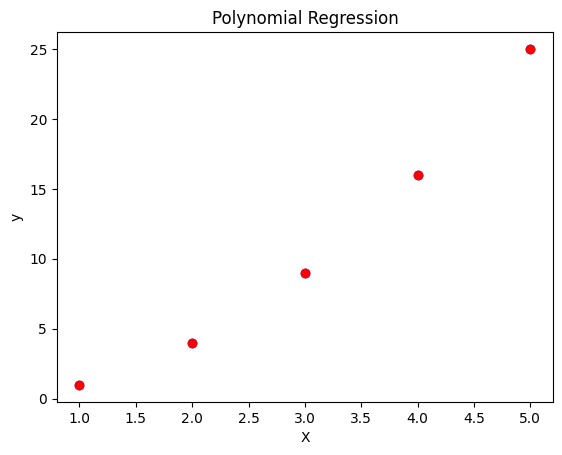

In [ ]:
import numpy as np 
from matplotlib import pyplot as plt

X = np.array([1,2,3,4,5], dtype=float)
y = np.array([1,4,9,16,25], dtype=float)

X_poly = np.column_stack((X, X**2))

w = np.zeros(2)
b = 0
learning_rate = 0.001

for i in range(5000):
    y_pred = np.dot(X_poly, w) + b
    loss = np.mean((y_pred - y) ** 2)

    dw = 2 * np.dot(X_poly.T, (y_pred - y)) / len(X_poly)
    db = 2 * np.mean(y_pred - y)

    w -= learning_rate * dw
    b -= learning_rate * db

    if i % 500 == 0:
        print(f"Iteration {i}, Loss: {loss:.4f}, w: {w}, b: {b}")

print(f"Final parameters: w: {w}, b: {b}")
print(f"Actual values: {y}")
print(f"Loss: {loss:.4f}")

plt.scatter(X, y, color='blue', label='Actual')
y_pred_final = np.dot(X_poly, w) + b
plt.scatter(X, y_pred_final, color='red', label='Predicted')
plt.xlabel('X')     
plt.ylabel('y')
plt.title('Polynomial Regression')

